# Model Analysis

This notebook includes analyses of trained RNN and SINDy models for the constant drift case (simpleDDM).

The RNNs have been trained from a ground-truth PyBeam simpleDDM model with boundary = 1.0, diffusion sigma = 1.0, non-decision time = 0.2 and evidence bias = 0.0. Drift rates are 4.0, 2.0, 1.0, 0.5 and 0.1, representing increasing difficulty in tasks.

Below we load the trained models for each drift rate. Model weights come from checkpoints saved on best KL-divergence.

We first plot the losses and accuracies of each model, followed by plots of stepwise drift and diffusion values of the RNN. Then, we fit a SINDy model to these values and display the discovered equation, as well as their initial values. We then simulate new choice-RTs from the RNN and the SINDy models, which we use later for model recovery and comparison.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from training_utils import get_lls

from regressors import RNNRegressor

### Loss and Accuracy Plots

The following plots show the training losses and accuracies of the RNNs and the discriminators. The RNN loss is the KL-divergence between the simulated RTs and the target RTs, while the discriminator loss is the percentage of batches in an epoch where the discriminator scored the real RTs higher than the RNN predictions.

In [6]:
path_ugm = 'experiments/nonlineardrift/20250829-182132'
paths = [path_ugm]

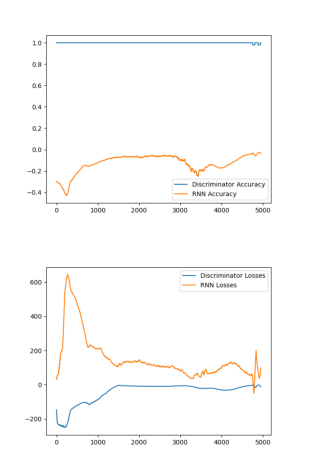

In [7]:
# fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig, axes = plt.subplots(2, 1)
for i, path in enumerate(paths):
    acc_path = f'{path}/figures/acc.png'
    loss_path = f'{path}/figures/loss.png'

    acc_img = plt.imread(acc_path)
    loss_img = plt.imread(loss_path)

    axes[0].imshow(acc_img)
    axes[0].axis('off')

    axes[1].imshow(loss_img)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Parameter Recovery

The following plots show the stepwise drift and diffusion values that the RNNs have learned. Each are taken from the first sequence. The threshold is also plotted for convenience.

### Load Models

First, we need to load the trained RNNs and their corresponding RTs. The RTs are used to simulate the same number of choice-RTs from the RNNs and later plot real and predicted RT distributions.

In [8]:
def load_rnn_regressor(experiment, device='cpu', min_dt=0.01, ln_dim=1):
    # Set paths
    checkpoint_load_path = f'{experiment}/checkpoint.pth'
    rt_load_path = f'{experiment}/rt.npy'
    config_file_path = f'{experiment}/config.yml'

    # Load config file
    with open(config_file_path, "r") as file:
        config = yaml.safe_load(file)

    rts_original = np.load(rt_load_path)
    t_max = np.max(abs(rts_original))

    rnn_regressor = RNNRegressor(hidden_dim=config['rnn_params']['hidden_dim'],
                                 hidden_layers=config['rnn_params']['hidden_layers'],
                                 lr=config['training_params']['lr'],
                                 batch_size=config['rnn_params']['batch_size'],
                                 train_interval=config['training_params']['train_interval'],
                                 init_evidence=0.,
                                 threshold=1.,
                                 t_max=t_max,
                                 checkpoint_load_path=checkpoint_load_path,
                                 save_path=None,
                                 device=device,
                                 logger=None,
                                 verbose=True,
                                 min_dt=min_dt)

    return rnn_regressor, rts_original, config, t_max

In [9]:
rnn_regressor_ugm, rts_original_ugm, config_ugm, t_max_ugm = load_rnn_regressor(path_ugm)

Loaded checkpoint from experiments/nonlineardrift/20250829-182132/checkpoint.pth


### Simulate RTs from RNNs

In [10]:
rts_rnn_ugm, traces_rnn_ugm, dt_rnn_ugm, decision_indices_ugm = rnn_regressor_ugm.predict(np.zeros(len(rts_original_ugm)))

Simulating RTs and evidence traces from RNN...
Done.


In [11]:
rts_rnn_ugm = rts_rnn_ugm.reshape(-1, 1)

### Stepwise Drift and Diffusion Plots

In [12]:
all_t = []
all_v = []
for i in range(10000):
    t = 0.0001 * (i + 1)
    all_t.append(t * 100)
    v = 0.5 + t / (1 + t)
    all_v.append(v)

In [13]:
traces_rnn_ugm['drift'][0][0]

0.38644886

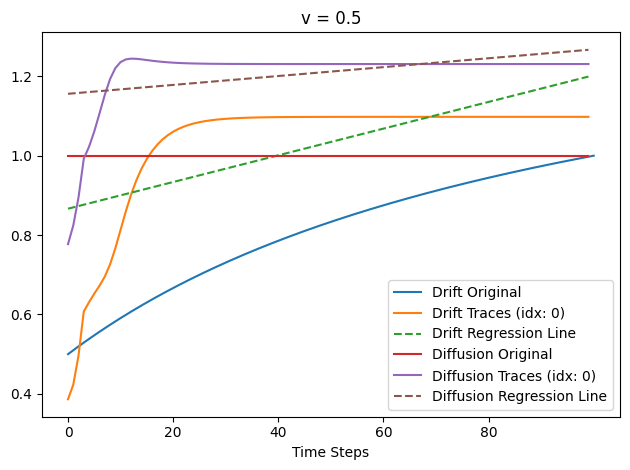

In [14]:
from sklearn.linear_model import LinearRegression

def plot_traces(traces_dict):
    fig, ax = plt.subplots()

    idx = 0
    seq = traces_rnn_ugm['evidence'][idx].size
    drifts = traces_rnn_ugm['drift'][idx, :seq]
    diffusions = traces_rnn_ugm['diffusion'][idx, :seq]
    threshold = rnn_regressor_ugm.rnn.threshold.detach().cpu().numpy()

    # Create x-axis values
    x = np.arange(len(drifts)).reshape(-1, 1)

    # Fit linear regression for drifts
    drift_model = LinearRegression()
    drift_model.fit(x, drifts)
    drift_line = drift_model.predict(x)

    # Fit linear regression for diffusions
    diffusion_model = LinearRegression()
    diffusion_model.fit(x, diffusions)
    diffusion_line = diffusion_model.predict(x)

    ax.plot(all_t, all_v, label='Drift Original')
    ax.plot(drifts, label='Drift Traces (idx: 0)')
    ax.plot(drift_line, label="Drift Regression Line", linestyle='--')
    ax.plot(np.full(drifts.shape, threshold), label='Diffusion Original')
    ax.plot(diffusions, label='Diffusion Traces (idx: 0)')
    ax.plot(diffusion_line, label="Diffusion Regression Line", linestyle='--')
    ax.set_title("v = 0.5")
    ax.set_xlabel('Time Steps')
    ax.legend()

    ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    # Hide the last empty subplot
    if len(traces_dict) < len(axes):
        for ax in axes[len(traces_dict):]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

traces_dict = {
    "v=0.5": [rnn_regressor_ugm, traces_rnn_ugm],
}

plot_traces(traces_dict)

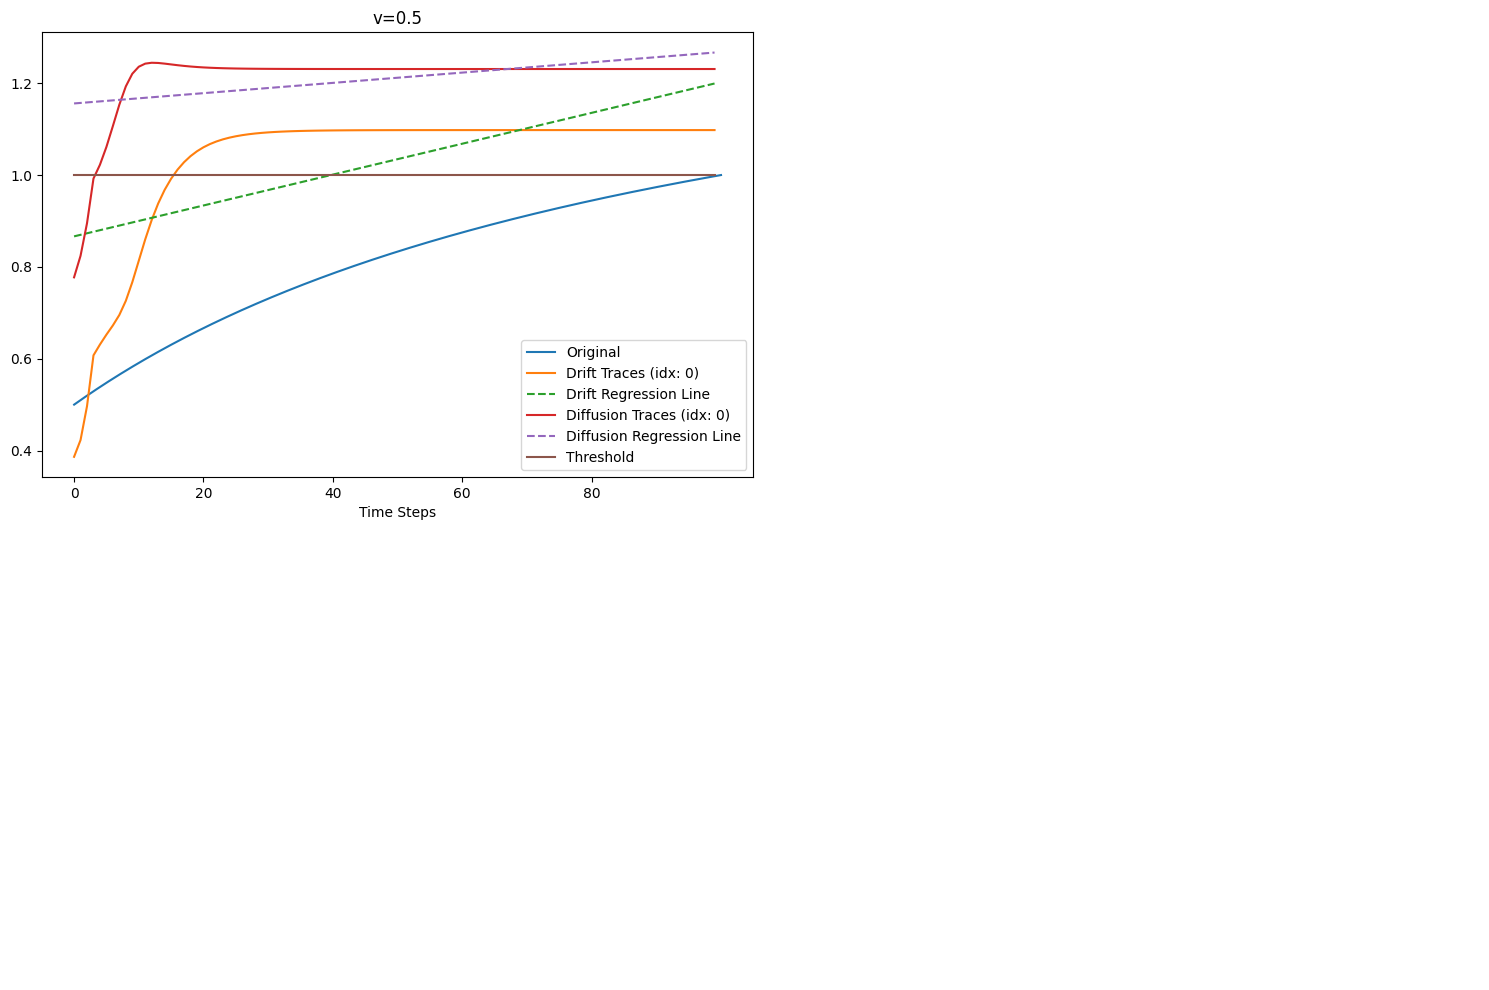

In [15]:
from sklearn.linear_model import LinearRegression

def plot_traces(traces_dict):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes = axes.flatten()

    for ax, (label, (rnn_regressor, traces)) in zip(axes, traces_dict.items()):
        idx = 0
        seq = traces['evidence'][idx].size
        drifts = traces['drift'][idx, :seq]
        diffusions = traces['diffusion'][idx, :seq]
        threshold = rnn_regressor.rnn.threshold.detach().cpu().numpy()

        # Create x-axis values
        x = np.arange(len(drifts)).reshape(-1, 1)

        # Fit linear regression for drifts
        drift_model = LinearRegression()
        drift_model.fit(x, drifts)
        drift_line = drift_model.predict(x)

        # Fit linear regression for diffusions
        diffusion_model = LinearRegression()
        diffusion_model.fit(x, diffusions)
        diffusion_line = diffusion_model.predict(x)

        ax.plot(all_t, all_v, label='Original')
        ax.plot(drifts, label='Drift Traces (idx: 0)')
        ax.plot(drift_line, label="Drift Regression Line", linestyle='--')
        ax.plot(diffusions, label='Diffusion Traces (idx: 0)')
        ax.plot(diffusion_line, label="Diffusion Regression Line", linestyle='--')
        ax.plot(np.full(drifts.shape, threshold), label='Threshold')
        ax.set_title(label)
        ax.set_xlabel('Time Steps')
        ax.legend()

        ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    # Hide the last empty subplot
    if len(traces_dict) < len(axes):
        for ax in axes[len(traces_dict):]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

traces_dict = {
    "v=0.5": [rnn_regressor_ugm, traces_rnn_ugm],
}

plot_traces(traces_dict)

In [16]:
import pandas as pd

def create_df(traces_dict):
    data = {
        'Drift Mean': [],
        'Drift Std': [],
        'Diffusion Mean': [],
        'Diffusion Std': [],
        'Drift / Diffusion': []
    }

    for label, (rnn_regressor, traces) in traces_dict.items():
        drift_means = []
        drift_stds = []
        diffusion_means = []
        diffusion_stds = []
        for idx in range(len(traces['evidence'])):
            seq = traces['evidence'][idx].size
            drifts = traces['drift'][idx, :seq]
            diffusions = traces['diffusion'][idx, :seq]

            drift_means.append(np.mean(drifts))
            drift_stds.append(np.std(drifts))
            diffusion_means.append(np.mean(diffusions))
            diffusion_stds.append(np.std(diffusions))

        data['Drift Mean'].append(np.mean(drift_means))
        data['Drift Std'].append(np.mean(drift_stds))
        data['Diffusion Mean'].append(np.mean(diffusion_means))
        data['Diffusion Std'].append(np.mean(diffusion_stds))
        data['Drift / Diffusion'].append(np.mean(drift_means) / np.mean(diffusion_means))

    df = pd.DataFrame(data, index=traces_dict.keys())
    return df

In [17]:
df = create_df(traces_dict)

In [68]:
df

,Drift Mean,Drift Std,Diffusion Mean,Diffusion Std,Drift / Diffusion
v=0.5,1.172474,0.340035,1.130966,0.016659,1.036701


### Fit SINDy model

The following code fits a SINDy model to the drift and diffusion values of the RNNs. The SINDy model is a sparse regression model that learns the underlying dynamics of the system. The SINDy model is fitted to the drift and diffusion values of the RNNs and the discovered equation is displayed.

In [18]:
np.stack([traces_rnn_ugm['drift'], traces_rnn_ugm['diffusion']], axis=-1)

array([[[0.38644886, 0.7772553 ],
        [0.42294216, 0.82417727],
        [0.4967121 , 0.8950561 ],
        ...,
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ]],

       [[0.38644886, 0.7772553 ],
        [0.42294216, 0.82417727],
        [0.4967121 , 0.8950561 ],
        ...,
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ]],

       [[0.38644886, 0.7772553 ],
        [0.42294216, 0.82417727],
        [0.4967121 , 0.8950561 ],
        ...,
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ]],

       ...,

       [[0.38644886, 0.7772553 ],
        [0.42294216, 0.82417727],
        [0.4967121 , 0.8950561 ],
        ...,
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ],
        [1.0979162 , 1.2308892 ]],

       [[0.38644886, 0.7772553 ],
        [0.42294216, 0.82417727],
        [0.4967121 , 0.8950561 ],
        .

In [19]:
import pysindy as ps
library = ps.PolynomialLibrary(2)

times = [np.arange(len(traces_rnn_ugm['drift'][i]))  / 0.01 for i in range(len(traces_rnn_ugm['drift']))]

sindy = ps.SINDy(
    optimizer=ps.SR3(verbose=True, threshold=0.5, fit_intercept=False),
    feature_library=library,
    discrete_time=True,
    feature_names=['v', 'sigma', 't'],
    t_default=0.01,
    differentiation_method=ps.SmoothedFiniteDifference(),
)

In [20]:
drift_traces = np.stack([traces_rnn_ugm['drift'], traces_rnn_ugm['diffusion'], times], axis=-1)

In [21]:
drift_traces = [t for t in drift_traces]

In [22]:
sindy.fit(drift_traces,
          ensemble=False,
          library_ensemble=False,
          multiple_trajectories=True,
          t=float(dt_rnn_ugm[0])
          )

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 2.3631e+02 ... 5.6546e-01 ... 7.5000e+00 ... 2.4437e+02
         3 ... 9.0590e+01 ... 5.8682e-01 ... 7.5000e+00 ... 9.8677e+01
         6 ... 7.3106e+01 ... 5.8424e-01 ... 7.5000e+00 ... 8.1190e+01
         9 ... 6.5014e+01 ... 5.8254e-01 ... 7.5000e+00 ... 7.3097e+01
        12 ... 6.1113e+01 ... 5.8252e-01 ... 7.5000e+00 ... 6.9196e+01
        15 ... 5.9151e+01 ... 5.8252e-01 ... 7.5000e+00 ... 6.7233e+01
        18 ... 5.8017e+01 ... 6.8257e-01 ... 7.5000e+00 ... 6.6200e+01
        21 ... 5.7332e+01 ... 5.9114e-01 ... 7.5000e+00 ... 6.5423e+01
        24 ... 5.6908e+01 ... 5.8270e-01 ... 7.5000e+00 ... 6.4990e+01
        27 ... 5.6572e+01 ... 5.8674e-01 ... 7.5000e+00 ... 6.4659e+01


/Users/imtezcan/.pyenv/versions/3.11.0/envs/ai4sci/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


SINDy(differentiation_method=SmoothedFiniteDifference(), discrete_time=True,
      feature_library=PolynomialLibrary(), feature_names=['v', 'sigma', 't'],
      optimizer=SR3(threshold=0.5, verbose=True), t_default=0.01)

In [23]:
sindy.print()

(v)[k+1] = 0.932 v[k]^2
(sigma)[k+1] = 0.073 1 + 2.441 v[k] + -1.263 v[k]^2
(t)[k+1] = 100.000 1 + 1.000 t[k]


### Predict from SINDy

Now that we have fitted the SINDy model, we can use it to predict stepwise drift and diffusion values. We will also calculate new choice-RTs from the SINDy model, which we will use later for model recovery and comparison.

In [24]:
sindy.equations()

['0.932 v[k]^2',
 '0.073 1 + 2.441 v[k] + -1.263 v[k]^2',
 '100.000 1 + 1.000 t[k]']

In [25]:
def sindy_predict(sindy, initial_v=0.5, initial_D=1.0, b=1.0, tnd=0.2, n_sims=8192, dt=0.1):
    rts = []

    for i in range(n_sims):
        v_t = initial_v
        D_t = initial_D
        x = 0
        count = 0
        while abs(x) < b:
            v_t = np.array(v_t).reshape(1, 1, 1)
            D_t = np.array(D_t).reshape(1, 1, 1)
            T_t = np.array(0).reshape(1, 1, 1)

            v_t, D_t, T_t = sindy.predict(np.stack((v_t, D_t, T_t), axis=-1), multiple_trajectories=False).squeeze()
            x += v_t * dt + D_t * np.sqrt(dt) * np.random.randn()
            count += 1
        rt = (tnd + dt * count) * np.sign(x)
        rts.append(rt)

    return rts

In [26]:
v_init_ugm = traces_rnn_ugm['drift'][0][0]
D_init_ugm = traces_rnn_ugm['diffusion'][0][0]

In [27]:
rts_sindy_ugm = sindy_predict(sindy, initial_v=v_init_ugm, initial_D=D_init_ugm, b=rnn_regressor_ugm.rnn.threshold.item(), dt=dt_rnn_ugm[0])

In [28]:
rts_sindy_ugm = np.array(rts_sindy_ugm).reshape(-1, 1)

### Plot Response Time Distributions from RNN and SINDy

Below we plot the response time distributions from the RNN and SINDy models, as well as the original RTs from the PyBeam model. The distributions are plotted as histograms.

NameError: name 'plot_rts_multi' is not defined

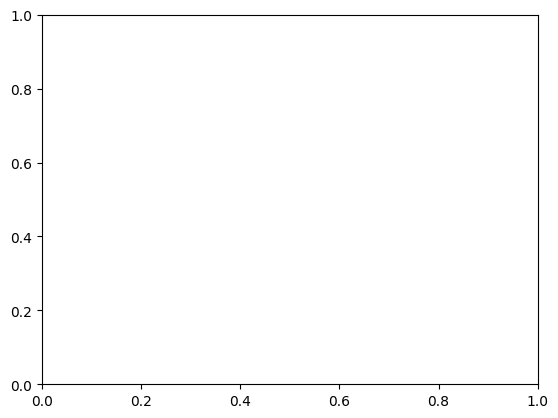

In [29]:
fig, ax = plt.subplots()

rt_dicts = [
    {
        'rts': [rts_original_ugm, rts_rnn_ugm, rts_sindy_ugm],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=0.5'
    }
]

plot_rts_multi(ax, rt_dicts[0])
ax.set_title(rt_dicts[0]['label'])

plt.tight_layout()
plt.show()
plt.close()

## Model Recovery

In this section, we will see how well the RNN and SINDy models performs in terms of log-likelihood on their own data. For comparison, we also fit a simple DDM and a full DDM model to the original data. We then fit Kernel Density Estimation (KDE) to the RTs from each model, as well as the original data. The KDE is used to estimate the probability density function of the RTs. Then, we score the log-likelihood of the KDE on the RTs from each model. The log-likelihood is a measure of how well the model fits the data. A higher log-likelihood indicates a better fit. Finally we create a heatmap from the results, comparing how well each model can fit the data from the other models.

### Fit SimpleDDM to Original Data

The following code fits a simpleDDM model to the original data and generates new choice-RTs from it. The simpleDDM model is the same model that the original data was generated from, so we expect it to have a good fit.

In [144]:
import pybeam.precoded as pbp
import pybeam.custom as pbc

Let's load parameter sets for all drift rates. The parameters are the same as the ones used to generate the original data.

In [145]:
phi_ugm = {
    'phi[0]': config_ugm['ddm_params']['tnd'],
    'phi[1]': config_ugm['ddm_params']['starting_point'],
    'phi[2]': config_ugm['ddm_params']['drift'],
    'phi[3]': config_ugm['ddm_params']['diffusion'],
    'phi[4]': config_ugm['ddm_params']['boundary']
}

# phi_ugm = {
#     'tnd': config_ugm['ddm_params']['tnd'],  # non-decision time
#     'w': config_ugm['ddm_params']['starting_point'],  # starting point
#     'mu': config_ugm['ddm_params']['drift'],  # drift rate
#     'b': config_ugm['ddm_params']['boundary'],  # threshold
#     'k': config_ugm['ddm_params']['urgency'],  # urgency
#     'l': config_ugm['ddm_params']['leakage']  # leakage
# }

In [146]:
model_dir_ugm = f'../../{config_ugm["simulation_params"]["path_pybeam_model"]}'

In [147]:
rts_original_ugm_upper = rts_original_ugm[rts_original_ugm >= 0]
rts_original_ugm_lower = -1 * rts_original_ugm[rts_original_ugm < 0]

rts_rnn_ugm_upper = rts_rnn_ugm[rts_rnn_ugm >= 0]
rts_rnn_ugm_lower = -1 * rts_rnn_ugm[rts_rnn_ugm < 0]

rts_sindy_ugm_upper = rts_sindy_ugm[rts_sindy_ugm >= 0]
rts_sindy_ugm_lower = -1 * rts_sindy_ugm[rts_sindy_ugm < 0]

In [148]:
pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})

-9528.347113615515

In [149]:
ll_pbc_ugm_original = pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})
ll_pbc_ugm_rnn = pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_rnn_ugm_upper, 'rt_lower': -1 * rts_rnn_ugm_lower})
ll_pbc_ugm_sindy = pbc.loglikelihood(model_dir=model_dir_ugm, phi=phi_ugm, rt={'rt_upper': rts_sindy_ugm_upper, 'rt_lower': -1 * rts_sindy_ugm_lower})
print(f'v = 4.0 \n LL - Original: {ll_pbc_ugm_original} \n LL - RNN: {ll_pbc_ugm_rnn} \n LL - SINDy: {ll_pbc_ugm_sindy}')

v = 4.0 
 LL - Original: -9528.347113615515 
 LL - RNN: -9857.55992374459 
 LL - SINDy: -48362.48236604654


In [150]:
simpleDDM = pbp.simpleDDM()

In [151]:
# define model priors
p = {
    'p_tnd': 'Uniform("t_nd", lower = 0.0, upper = 0.5)',  # non-decision time prior
    'p_w': 'Uniform("w", lower = 0.1, upper = 0.9)',  # relative start point prior
    'p_b': 'Uniform("b", lower = 0.1, upper = 2.0)',  # decision threshold prior
    'p_mu0': 'Uniform("mu0", lower = -5.0, upper = 5.0)', # drift rate priors
}

# define model conditions
c0 = {'rt' : {'rt_upper': rts_original_ugm_upper, 'rt_lower': rts_original_ugm_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu0',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

# load conditions into dictionary
c = {0 : c0} # dictionary containing conditions

In [152]:
# run parameter inference
idata = pbp.inference(model = simpleDDM,       # model dictionary
                     priors = p,           # priors dictionary
                 conditions = c,           # conditions dictionary
                    samples = 25000,       # number of MCMC samples
                     chains = 3,           # number of MCMC chains
                      cores = 3,           # number of CPU cores to run chains on
                  file_name = 'simpleDDM') # file output

Multiprocess sampling (3 chains in 3 jobs)
DEMetropolisZ: [t_nd, w, b, mu0]


Output()

/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),


Sampling 3 chains for 0 tune and 25_000 draw iterations (0 + 75_000 draws total) took 33 seconds.


array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'mu0'}>, <Axes: title={'center': 'mu0'}>],
       [<Axes: title={'center': 't_nd'}>,
        <Axes: title={'center': 't_nd'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

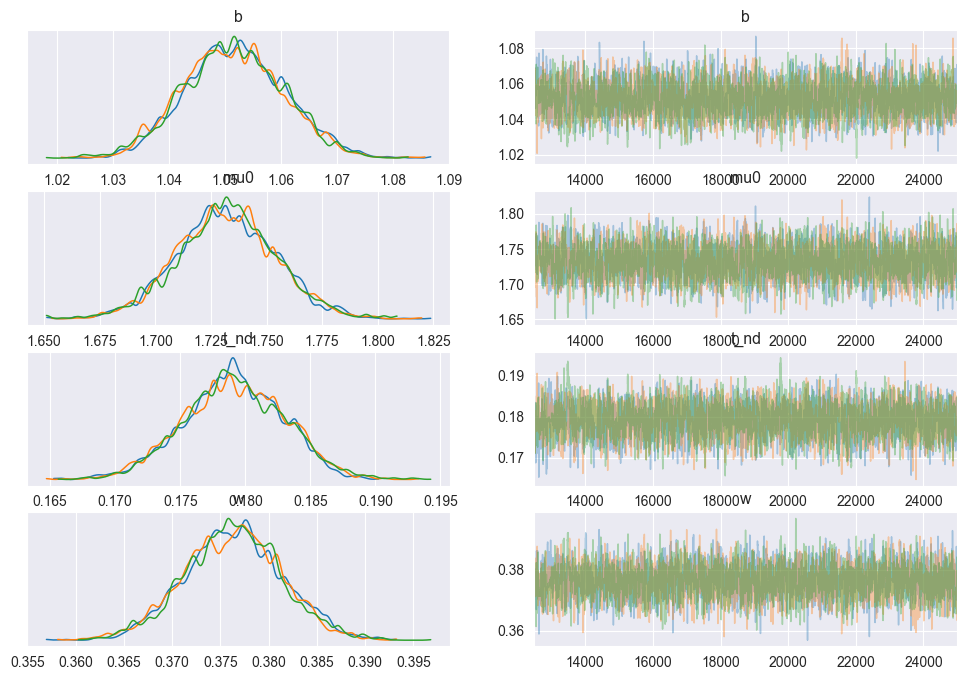

In [153]:
pbp.plot_idata(file_name='simpleDDM', burnin = 12500)

In [154]:
df_simpleddm = pbp.summary(file_name = 'simpleDDM', burnin = 12500)
df_simpleddm

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,1.052,0.009,1.035,1.068,0.0,0.0,2504.0,3193.0,1.0
mu0,1.732,0.022,1.692,1.775,0.0,0.0,2499.0,3242.0,1.0
t_nd,0.179,0.004,0.172,0.186,0.0,0.0,2314.0,2852.0,1.0
w,0.376,0.005,0.367,0.386,0.0,0.0,2386.0,3343.0,1.0


In [155]:
variables = ["b", "mu0", "t_nd", "w"]
means_dict = {var: idata.posterior[var].mean(dim=["chain", "draw"]).item() for var in variables}

# Rename 't_nd' to 'tnd'
means_dict['tnd'] = means_dict.pop('t_nd')
print(means_dict)

{'b': 1.048045207975131, 'mu0': 1.7166864764289536, 'w': 0.37945078570640445, 'tnd': 0.18106495645511023}


In [156]:
# Create 5 new phi_n dictionaries from means_dict. b, tnd, w are the same for all phi_n dictionaries. mu0, mu1, mu2, mu3, mu4 are different for each phi_n dictionary. name nem phi_ugm, phi_2_0, phi_1_0, phi_0_5, phi_0_1.
phi_ugm_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu0'],
}

In [157]:
ll_fitted_simpleddm_original_ugm = pbp.loglikelihood(simpleDDM, phi_ugm_simpleddm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})
ll_fitted_simpleddm_rnn_ugm = pbp.loglikelihood(simpleDDM, phi_ugm_simpleddm, rt={'rt_upper': rts_rnn_ugm_upper, 'rt_lower': -1 * rts_rnn_ugm_lower})
ll_fitted_simpleddm_sindy_ugm = pbp.loglikelihood(simpleDDM, phi_ugm_simpleddm, rt={'rt_upper': rts_sindy_ugm_upper, 'rt_lower': -1 * rts_sindy_ugm_lower})
print(f'v = 4.0 \n LL - Original: {ll_fitted_simpleddm_original_ugm} \n LL - RNN: {ll_fitted_simpleddm_rnn_ugm} \n LL - SINDy: {ll_fitted_simpleddm_sindy_ugm}')

v = 4.0 
 LL - Original: -9717.33529040118 
 LL - RNN: -10100.472077585266 
 LL - SINDy: -42718.1233329199


### Fit FullDDM to Original Data

In [158]:
fullDDM = pbp.fullDDM()

In [199]:
p = {
    'p_tnd': 'Uniform("tnd", lower = 0.0, upper = 1.0)',
    'p_sd_tnd': 'Uniform("sd_tnd", lower = 0.001, upper = 0.25)',
    'p_w': 'Uniform("w", lower = 0.25, upper = 0.75)',
    'p_sd_w': 'Uniform("sd_w", lower = 0.01, upper = 0.99)',
    'p_mu0': 'Uniform("mu0", lower = -5.0, upper = 5.0)',
    'p_sd_mu0': 'Uniform("sd_mu0", lower = 0.001, upper = 5.0)',
    'p_b': 'Uniform("b", lower = 0.1, upper = 2.5)'
}

c0 = {
    'rt': {'rt_upper': rts_original_ugm_upper, 'rt_lower': rts_original_ugm_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu0',
    'sd_mu': 'p_sd_mu0',
    'b': 'p_b'
}

c = {0: c0}

idata_fullddm = pbp.inference(
    model=fullDDM,
    priors=p,
    conditions=c,
    samples=25000,
    chains=3,
    cores=3,
    file_name='DDM'
)

Multiprocess sampling (3 chains in 3 jobs)
DEMetropolisZ: [tnd, sd_tnd, w, sd_w, mu0, sd_mu0, b]


Output()

/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),


Sampling 3 chains for 0 tune and 25_000 draw iterations (0 + 75_000 draws total) took 309 seconds.


array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'mu0'}>, <Axes: title={'center': 'mu0'}>],
       [<Axes: title={'center': 'sd_mu0'}>,
        <Axes: title={'center': 'sd_mu0'}>],
       [<Axes: title={'center': 'sd_tnd'}>,
        <Axes: title={'center': 'sd_tnd'}>],
       [<Axes: title={'center': 'sd_w'}>,
        <Axes: title={'center': 'sd_w'}>],
       [<Axes: title={'center': 'tnd'}>, <Axes: title={'center': 'tnd'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

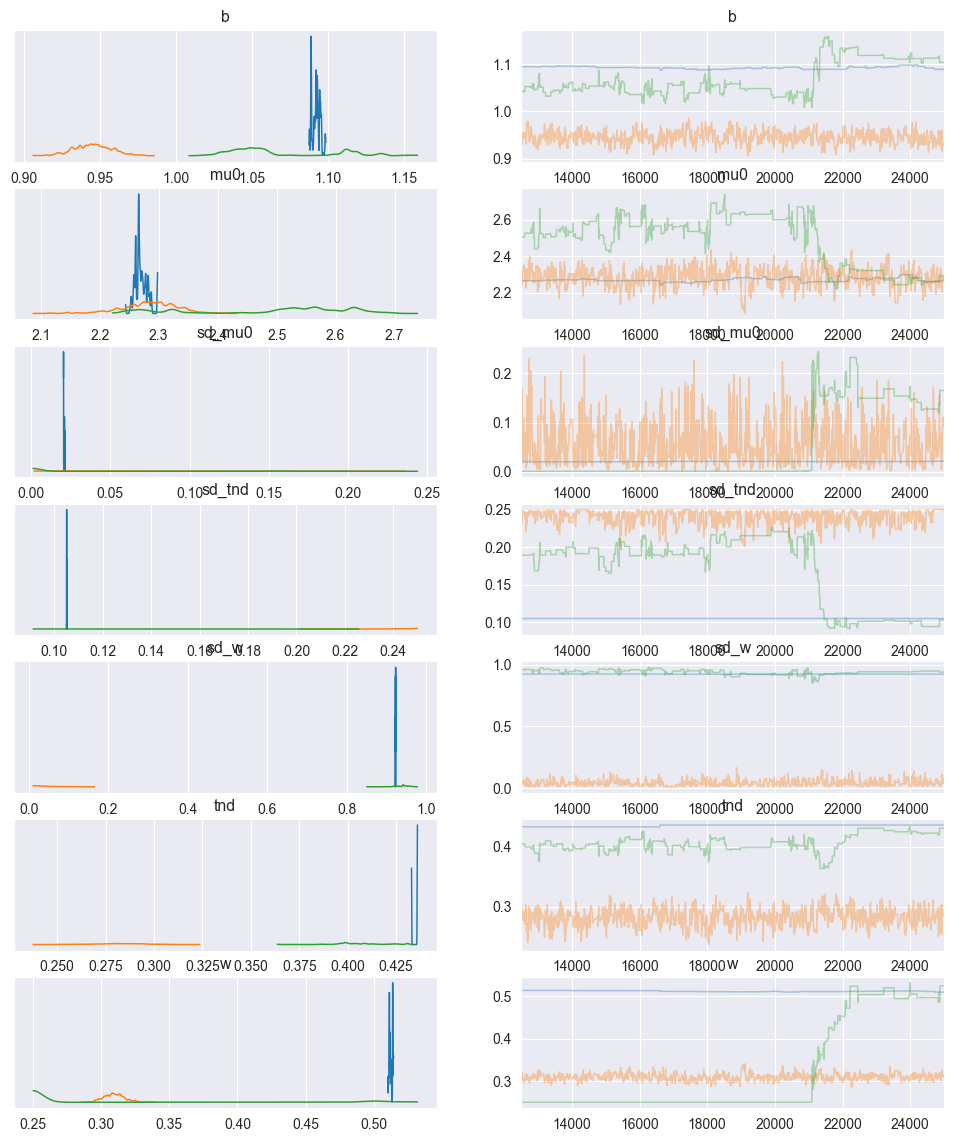

In [200]:
pbp.plot_idata(file_name='DDM', burnin = 12500)

In [201]:
df_fullddm = pbp.summary(file_name = 'DDM', burnin = 12500)
df_fullddm

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,1.035,0.068,0.930,1.119,0.038,0.030,4.0,23.0,2.15
mu0,2.347,0.130,2.218,2.633,0.063,0.048,7.0,52.0,1.48
sd_mu0,0.042,0.051,0.001,0.153,0.019,0.014,5.0,19.0,1.82
sd_tnd,0.172,0.062,0.101,0.249,0.033,0.026,4.0,10.0,1.88
sd_w,0.634,0.421,0.012,0.959,0.243,0.192,4.0,29.0,2.54
tnd,0.375,0.067,0.270,0.436,0.038,0.030,4.0,44.0,2.46
w,0.381,0.113,0.250,0.514,0.059,0.046,4.0,16.0,2.13


In [202]:
# Convert to means_dict like before but for fullDDM
variables = ["b", "mu0", "sd_mu0", "tnd", "sd_tnd", "w", "sd_w"]
means_dict_fullddm = {var: idata_fullddm.posterior[var].mean(dim=["chain", "draw"]).item() for var in variables}

In [203]:
# Create 5 new phi_n dictionaries from means_dict_fullddm. b, tnd, w are the same for all phi_n dictionaries. mu0, mu1, mu2, mu3, mu4 and their sd_ variants are different for each phi_n dictionary. name them phi_ugm_fullddm, phi_2_0_fullddm, phi_1_0_fullddm, phi_0_5_fullddm, phi_0_1_fullddm.
phi_ugm_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu0'],
    "sd_mu": means_dict_fullddm['sd_mu0'],
}

In [204]:
ll_fitted_fullddm_original_ugm = pbp.loglikelihood(fullDDM, phi_ugm_fullddm, rt={'rt_upper': rts_original_ugm_upper, 'rt_lower': -1 * rts_original_ugm_lower})
ll_fitted_fullddm_rnn_ugm = pbp.loglikelihood(fullDDM, phi_ugm_fullddm, rt={'rt_upper': rts_rnn_ugm_upper, 'rt_lower': -1 * rts_rnn_ugm_lower})
ll_fitted_fullddm_sindy_ugm = pbp.loglikelihood(fullDDM, phi_ugm_fullddm, rt={'rt_upper': rts_sindy_ugm_upper, 'rt_lower': -1 * rts_sindy_ugm_lower})
print(f'v = 4.0 \n LL - Original: {ll_fitted_fullddm_original_ugm} \n LL - RNN: {ll_fitted_fullddm_rnn_ugm} \n LL - SINDy: {ll_fitted_fullddm_sindy_ugm}')

v = 4.0 
 LL - Original: -9908.199539657056 
 LL - RNN: -10227.59779315391 
 LL - SINDy: -45048.482296758106


### Simulate new data from fitted models

In [205]:
rt_dict_simpleddm_ugm = pbp.simulate(N_sims=rts_original_ugm.size, model=simpleDDM, phi=phi_ugm_simpleddm)
rts_simpleddm_ugm_upper = rt_dict_simpleddm_ugm['rt_upper']
rts_simpleddm_ugm_lower = rt_dict_simpleddm_ugm['rt_lower']
rts_simple_ddm_ugm = np.concatenate([rts_simpleddm_ugm_upper, -1 * rts_simpleddm_ugm_lower])


In [206]:
rt_dict_fullddm_ugm = pbp.simulate(N_sims=rts_original_ugm.size, model=fullDDM, phi=phi_ugm_fullddm)
rts_fullddm_ugm_upper = rt_dict_fullddm_ugm['rt_upper']
rts_fullddm_ugm_lower = rt_dict_fullddm_ugm['rt_lower']
rts_fullddm_ugm = np.concatenate([rts_fullddm_ugm_upper, -1 * rts_fullddm_ugm_lower])


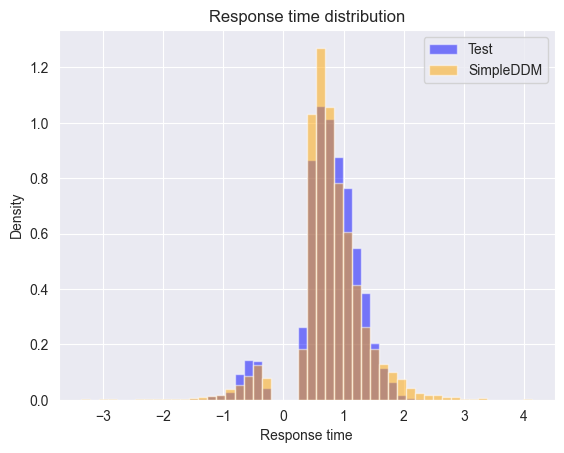

In [207]:
rt_dict = {
    'rts': [rts_original_ugm, rts_simple_ddm_ugm],#, rts_fullddm_ugm],
    'labels': ['Test', 'SimpleDDM'],#, 'FullDDM'],
    'colors': ['blue', 'orange']#, 'green']
}

fig, ax = plt.subplots()
plot_rts_multi(ax, rt_dict)

plt.show()
plt.close()

### Fit Kernel Density Estimation to each RT set and compare log-likelihoods against each other

For each drift rate, we fit KDEs to each RT set and then compare how well all RTs score against all KDEs.

First, we do cross-validation to find the best bandwidth and kernel for the KDEs.

In [208]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

params = {'bandwidth': np.logspace(-3, 1, 30), 'kernel': ['gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear']}
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_ugm)
bandwidth_ugm = grid.best_params_['bandwidth']
kernel_ugm = grid.best_params_['kernel']
print(f'v = 4.0 - Best bandwidth: {bandwidth_ugm} Best kernel: {kernel_ugm}')

v = 4.0 - Best bandwidth: 0.03290344562312668 Best kernel: gaussian


/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


In [209]:
import seaborn as sns

def get_lls_multi(rt_dict, bandwidth='scott', spacing=1000, bins=50, kernel='gaussian'):
    n_sets = len(rt_dict['rts'])
    kdes = []

    # Fit KDEs for each RT set
    for rts in rt_dict['rts']:
        kde = KernelDensity(bandwidth=bandwidth, kernel=kernel).fit(rts.reshape(-1, 1))
        kdes.append(kde)

    # Calculate log-likelihoods matrix
    ll_matrix = np.zeros((n_sets, n_sets))
    for i in range(n_sets):
        for j in range(n_sets):
            # Score RT set i against KDE j
            ll_matrix[i, j] = kdes[j].score(rt_dict['rts'][i].reshape(-1, 1)) / rt_dict['rts'][i].shape[0]

    # Plotting
    # KDE visualization
    plt.figure(figsize=(10, 6))

    # Find global min and max for x_grid
    min_val = min(rt.min() for rt in rt_dict['rts'])
    max_val = max(rt.max() for rt in rt_dict['rts'])
    x_grid = np.linspace(min_val, max_val, spacing)

    # Plot histograms and KDEs
    for i, (rts, label) in enumerate(zip(rt_dict['rts'], rt_dict['labels'])):
        plt.hist(rts, bins=bins, density=True, alpha=0.5, label=f'{label} (hist)')
        pdf = np.exp(kdes[i].score_samples(x_grid.reshape(-1, 1)))
        plt.plot(x_grid, pdf, '-', label=f'{label} (KDE)')

    plt.legend()
    plt.xlabel('Response Time')
    plt.ylabel('Density')
    plt.title('KDE of Response Time Distributions')
    plt.show()

    # Log-likelihood heatmap
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(ll_matrix, annot=True, fmt=".2f", cmap="Blues",
                     cbar_kws={'label': 'Log-Likelihood'})
    ax.set_xticklabels(rt_dict['labels'])
    ax.set_yticklabels(rt_dict['labels'], rotation=0)
    plt.xlabel('Response Times')
    plt.ylabel('Kernel Density Estimators')
    plt.title('Log-Likelihood Heatmap')
    plt.show()

    return ll_matrix

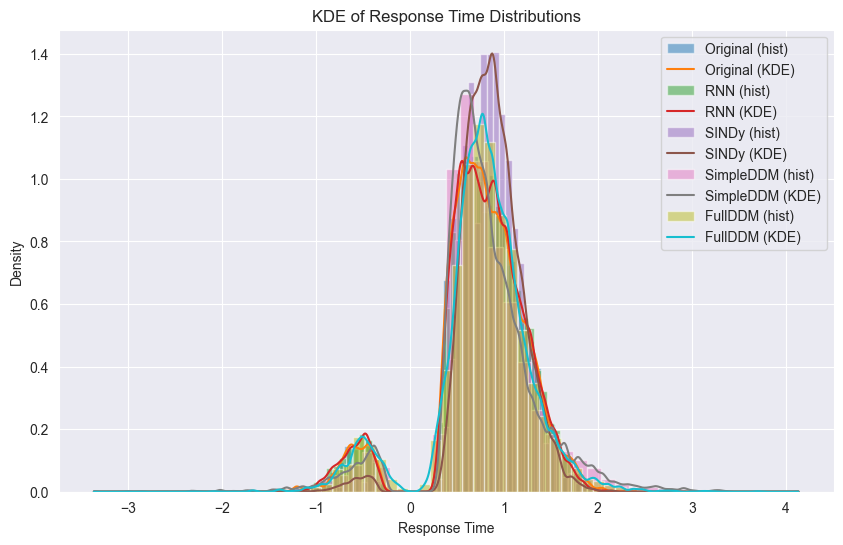

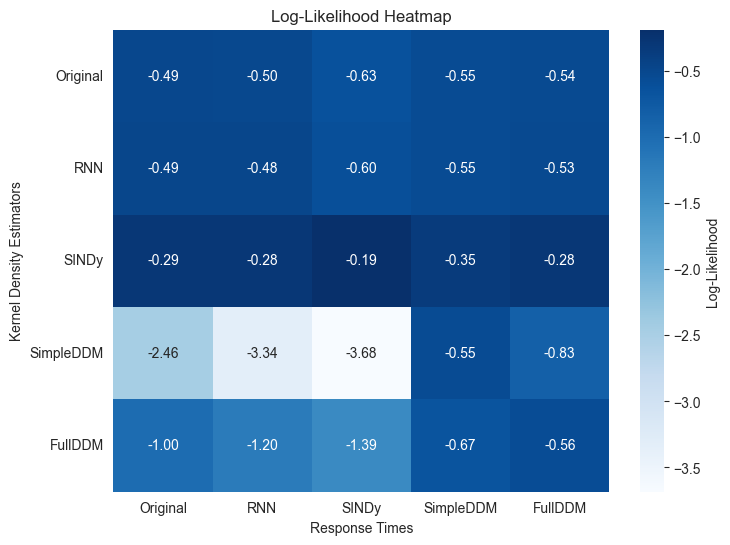

In [210]:
ll_matrix_ugm = get_lls_multi({"rts": [rts_original_ugm, rts_rnn_ugm, rts_sindy_ugm,
                rts_simple_ddm_ugm, rts_fullddm_ugm],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_ugm,
              kernel=kernel_ugm)

## Model Comparison

For each drift rate, we fit a single KDE and score each model's performance against it. We do this for 10 times for each model. We then compare the log-likelihoods of each model in a box plot.

### v = 4.0

In [214]:
n_trials = 10
n_sims = rts_original_ugm.size

all_rts_original_ugm = []
all_rts_rnn_ugm = []
all_rts_sindy_ugm = []
all_rts_simple_ddm_ugm = []
all_rts_fullddm_ugm = []

lls_original_ugm = []
lls_rnn_ugm = []
lls_sindy_ugm = []
lls_simple_ddm_ugm = []
lls_fullddm_ugm = []

kde_test = KernelDensity(bandwidth=bandwidth_ugm, kernel=kernel_ugm).fit(rts_original_ugm)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_ugm['simulation_params']['path_pybeam_model']}", phi_ugm, get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_ugm.append(rts_original)
    lls_original_ugm.append(kde_test.score(rts_original))

    rts_rnn, traces, dt, decision_indices = rnn_regressor_ugm.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_ugm.append(rts_rnn)
    lls_rnn_ugm.append(kde_test.score(rts_rnn))

    # v_init = traces['drift'][0][0]
    # D_init = v_init = traces['diffusion'][0][0]
    # rts_sindy = sindy_predict(sindy_regressor_ugm.sindy, initial_v=v_init, initial_D=D_init, b=rnn_regressor_ugm.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    # rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    # all_rts_sindy_ugm.append(rts_sindy)
    # lls_sindy_ugm.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_ugm.size, model=simpleDDM, phi=phi_ugm_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_ugm.append(rts_simpleddm)
    lls_simple_ddm_ugm.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_ugm.size, model=fullDDM, phi=phi_ugm_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_ugm.append(rts_fullddm)
    lls_fullddm_ugm.append(kde_test.score(rts_fullddm))

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


In [215]:
lls_original_ugm = np.array(lls_original_ugm)
print(f'PyBeam LL Mean: {lls_original_ugm.mean()}, std: {lls_original_ugm.std()}')
lls_rnn_ugm = np.array(lls_rnn_ugm)
print(f'RNN LL Mean: {lls_rnn_ugm.mean()}, std: {lls_rnn_ugm.std()}')
# lls_sindy_ugm = np.array(lls_sindy_ugm)
# print(f'SINDy LL Mean: {lls_sindy_ugm.mean()}, std: {lls_sindy_ugm.std()}')
lls_simple_ddm_ugm = np.array(lls_simple_ddm_ugm)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_ugm.mean()}, std: {lls_simple_ddm_ugm.std()}')
lls_fullddm_ugm = np.array(lls_fullddm_ugm)
print(f'FullDDM LL Mean: {lls_fullddm_ugm.mean()}, std: {lls_fullddm_ugm.std()}')

PyBeam LL Mean: -4099.825209813197, std: 47.14523323620173
RNN LL Mean: -3917.4685265959715, std: 61.03110830779112
SimpleDDM LL Mean: -19756.50290017747, std: 3587.9636611077754
FullDDM LL Mean: -7504.675479109118, std: 869.100590898946


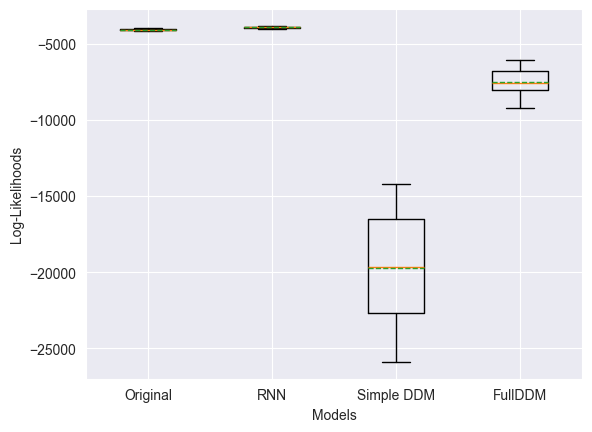

In [245]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_ugm, lls_rnn_ugm, lls_simple_ddm_ugm, lls_fullddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'Simple DDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

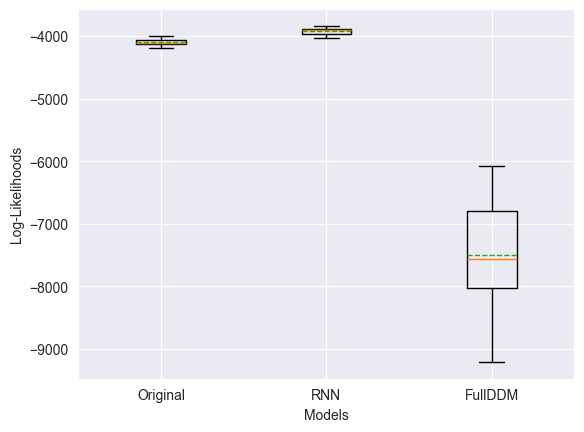

In [249]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_ugm, lls_rnn_ugm, lls_fullddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

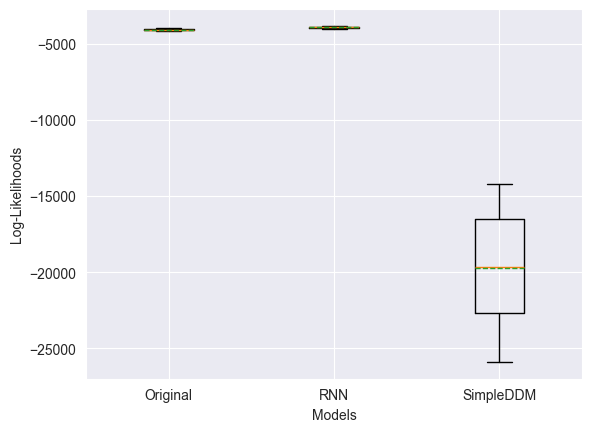

In [217]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_ugm, lls_rnn_ugm, lls_simple_ddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

In [246]:
lls_original_ugm_norm = lls_original_ugm.mean() / n_sims
lls_rnn_ugm_norm = lls_rnn_ugm.mean() / n_sims
lls_simple_ddm_ugm_norm = lls_simple_ddm_ugm.mean() / n_sims
lls_fullddm_ugm_norm = lls_fullddm_ugm.mean() / n_sims

In [247]:
print('Normalized LLs')
print(f'Original: {lls_original_ugm_norm}')
print(f'RNN: {lls_rnn_ugm_norm}')
print(f'SimpleDDM: {lls_simple_ddm_ugm_norm}')
print(f'FullDDM: {lls_fullddm_ugm_norm}')

Normalized LLs
Original: -0.500466944557275
RNN: -0.4782066072504848
SimpleDDM: -2.41168248293182
FullDDM: -0.9160980809459373


In [248]:
p_original_ugm = lls_original_ugm / n_sims
p_rnn_ugm = lls_rnn_ugm / n_sims
p_sindy_ugm = lls_sindy_ugm / n_sims
p_simple_ddm_ugm = lls_simple_ddm_ugm / n_sims
p_fullddm_ugm = lls_fullddm_ugm / n_sims

TypeError: unsupported operand type(s) for /: 'list' and 'int'

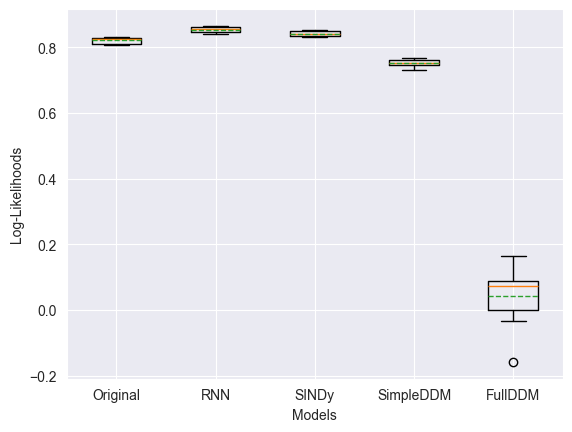

In [140]:
fig, ax = plt.subplots()
ax.boxplot([p_original_ugm, p_rnn_ugm, p_sindy_ugm, p_simple_ddm_ugm, p_fullddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

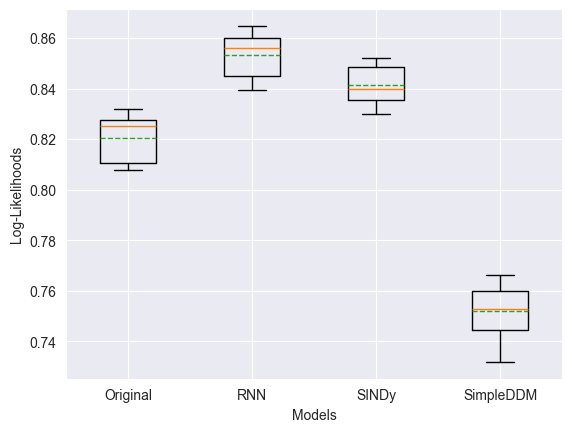

In [141]:
fig, ax = plt.subplots()
ax.boxplot([p_original_ugm, p_rnn_ugm, p_sindy_ugm, p_simple_ddm_ugm], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

In [142]:
print(f'LL Original mean: {p_original_ugm.mean()}, std: {p_original_ugm.std()}')
print(f'LL RNN mean: {p_rnn_ugm.mean()}, std: {p_rnn_ugm.std()}')
print(f'LL SINDy mean: {p_sindy_ugm.mean()}, std: {p_sindy_ugm.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_ugm.mean()}, std: {p_simple_ddm_ugm.std()}')
print(f'LL FullDDM mean: {p_fullddm_ugm.mean()}, std: {p_fullddm_ugm.std()}')

LL Original mean: 0.8204165188197929, std: 0.009144934563174051
LL RNN mean: 0.8534344248938135, std: 0.008578458403674768
LL SINDy mean: 0.8413998605339097, std: 0.00738833474549473
LL SimpleDDM mean: 0.7518476332037837, std: 0.010321781030189252
LL FullDDM mean: 0.042208305797623066, std: 0.08547724453108868
